# ML Lab 5: USA Housing Dataset
## Logistic Regression - Data Statistics, Preprocessing, Encoding, Feature Selection & Model Evaluation

**Objective:** Apply feature engineering, encoding techniques, feature selection, and build a Logistic Regression model on the USA Housing dataset.

---

## 1. Import Libraries

In [4]:
# Install kagglehub if not already installed
# pip install kagglehub[pandas-datasets]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, precision_recall_curve)
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load the USA Housing Dataset

In [5]:
# Load the USA Housing dataset from Kaggle using kagglehub
# First download the dataset, then load it with pandas
dataset_path = kagglehub.dataset_download('aariyan101/usa-housingcsv')

import os
# Find the CSV file in the downloaded dataset
csv_file = None
for f in os.listdir(dataset_path):
    if f.endswith('.csv'):
        csv_file = os.path.join(dataset_path, f)
        break

df = pd.read_csv(csv_file)

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"\nColumn names: {list(df.columns)}")
df.head(10)

100%|██████████| 363k/363k [00:01<00:00, 303kB/s]

Extracting files...
Dataset loaded successfully!
Shape: (5000, 7)

Column names: ['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address']


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386
5,80175.754159,4.988408,6.104512,4.04,26748.428425,1.068138e+06,"06039 Jennifer Islands Apt. 443\nTracyport, KS..."
6,64698.463428,6.025336,8.147760,3.41,60828.249085,1.502056e+06,"4759 Daniel Shoals Suite 442\nNguyenburgh, CO ..."
7,78394.339278,6.989780,6.620478,2.42,36516.358972,1.573937e+06,"972 Joyce Viaduct\nLake William, TN 17778-6483"
8,59927.660813,5.362126,6.393121,2.30,29387.396003,7.988695e+05,USS Gilbert\nFPO AA 20957
9,81885.927184,4.423672,8.167688,6.10,40149.965749,1.545155e+06,Unit 9446 Box 0958\nDPO AE 97025


## 3. Data Statistics (Exploratory Data Analysis)

In [6]:
# Basic info about the dataset
print("="*60)
print("DATASET INFORMATION")
print("="*60)
print(f"\nNumber of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")
print(f"\nColumn names: {list(df.columns)}")
print(f"\nData types:\n{df.dtypes}")
print("\n" + "="*60)
print("DATASET INFO")
print("="*60)
df.info()

DATASET INFORMATION

Number of rows: 5000
Number of columns: 7

Column names: ['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population', 'Price', 'Address']

Data types:
Avg. Area Income                float64
Avg. Area House Age             float64
Avg. Area Number of Rooms       float64
Avg. Area Number of Bedrooms    float64
Area Population                 float64
Price                           float64
Address                             str
dtype: object

DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Are

In [7]:
# Descriptive statistics
print("="*60)
print("DESCRIPTIVE STATISTICS")
print("="*60)
df.describe().T

DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max
Avg. Area Income,5000.0,6.858311e+04,10657.991214,17796.631190,61480.562388,6.880429e+04,7.578334e+04,1.077017e+05
Avg. Area House Age,5000.0,5.977222e+00,0.991456,2.644304,5.322283,5.970429e+00,6.650808e+00,9.519088e+00
Avg. Area Number of Rooms,5000.0,6.987792e+00,1.005833,3.236194,6.299250,7.002902e+00,7.665871e+00,1.075959e+01
Avg. Area Number of Bedrooms,5000.0,3.981330e+00,1.234137,2.000000,3.140000,4.050000e+00,4.490000e+00,6.500000e+00
Area Population,5000.0,3.616352e+04,9925.650114,172.610686,29403.928702,3.619941e+04,4.286129e+04,6.962171e+04
Price,5000.0,1.232073e+06,353117.626581,15938.657923,997577.135049,1.232669e+06,1.471210e+06,2.469066e+06


In [8]:
# Check for missing values
print("="*60)
print("MISSING VALUES")
print("="*60)
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")

# Check for duplicate rows
print(f"\nDuplicate rows: {df.duplicated().sum()}")

MISSING VALUES
Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

Total missing values: 0

Duplicate rows: 0


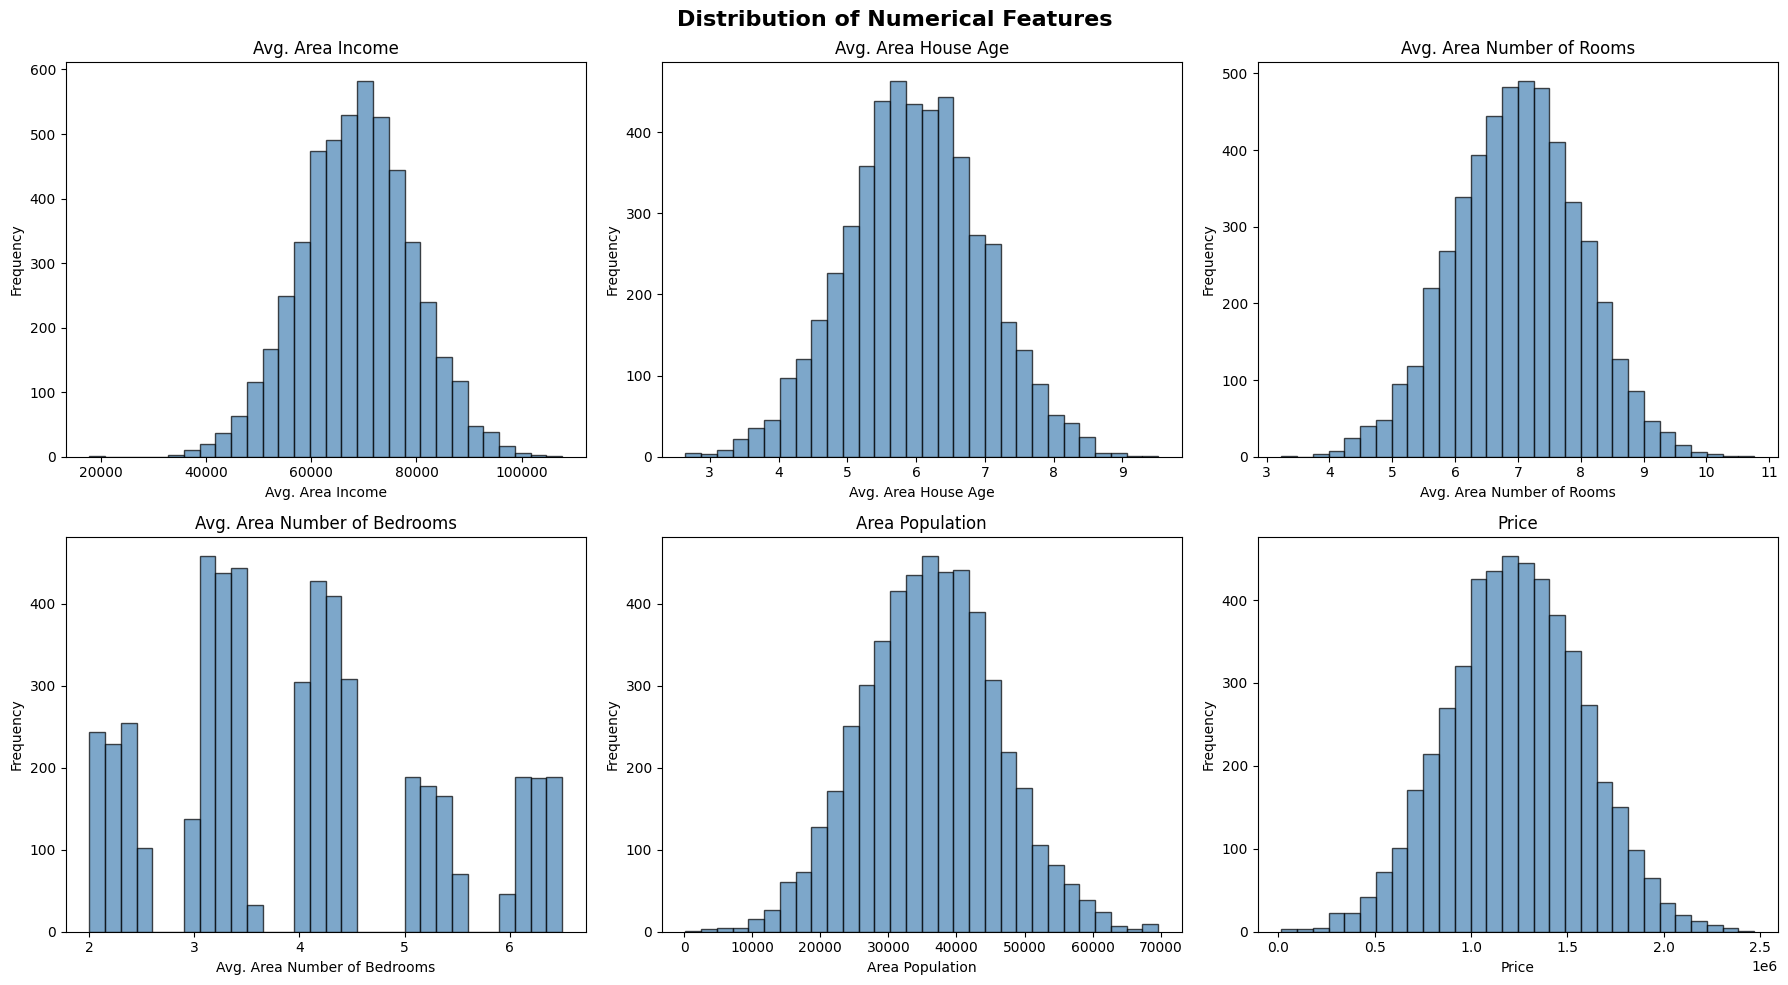

In [9]:
# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold')

numeric_cols = df.select_dtypes(include=[np.number]).columns
for idx, col in enumerate(numeric_cols):
    ax = axes[idx // 3, idx % 3]
    ax.hist(df[col], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
    ax.set_title(col, fontsize=12)
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.show()

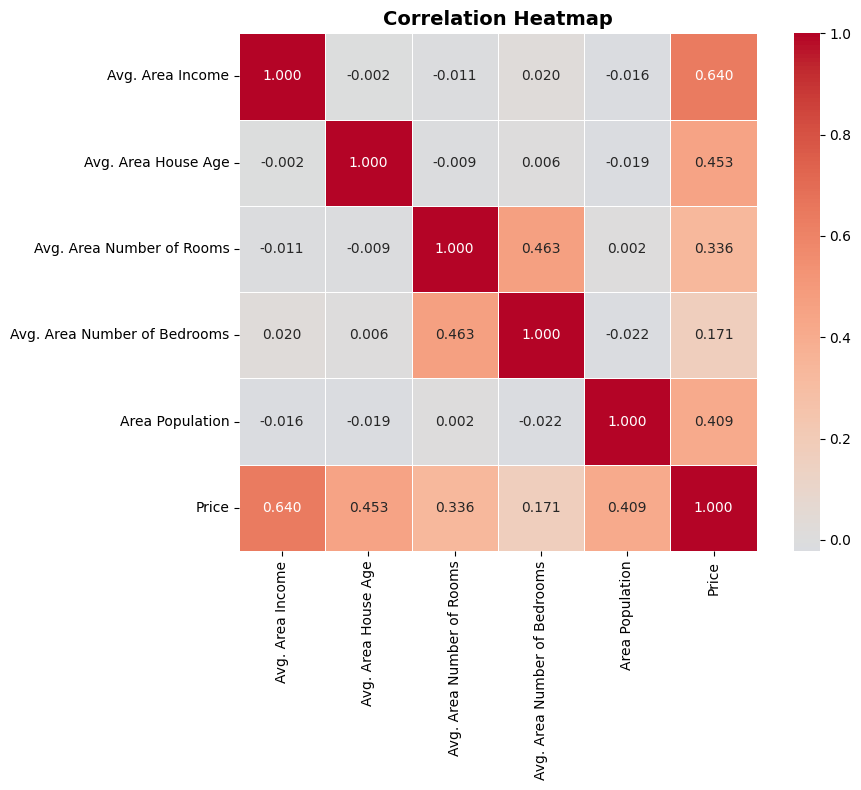

In [10]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
corr_matrix = df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

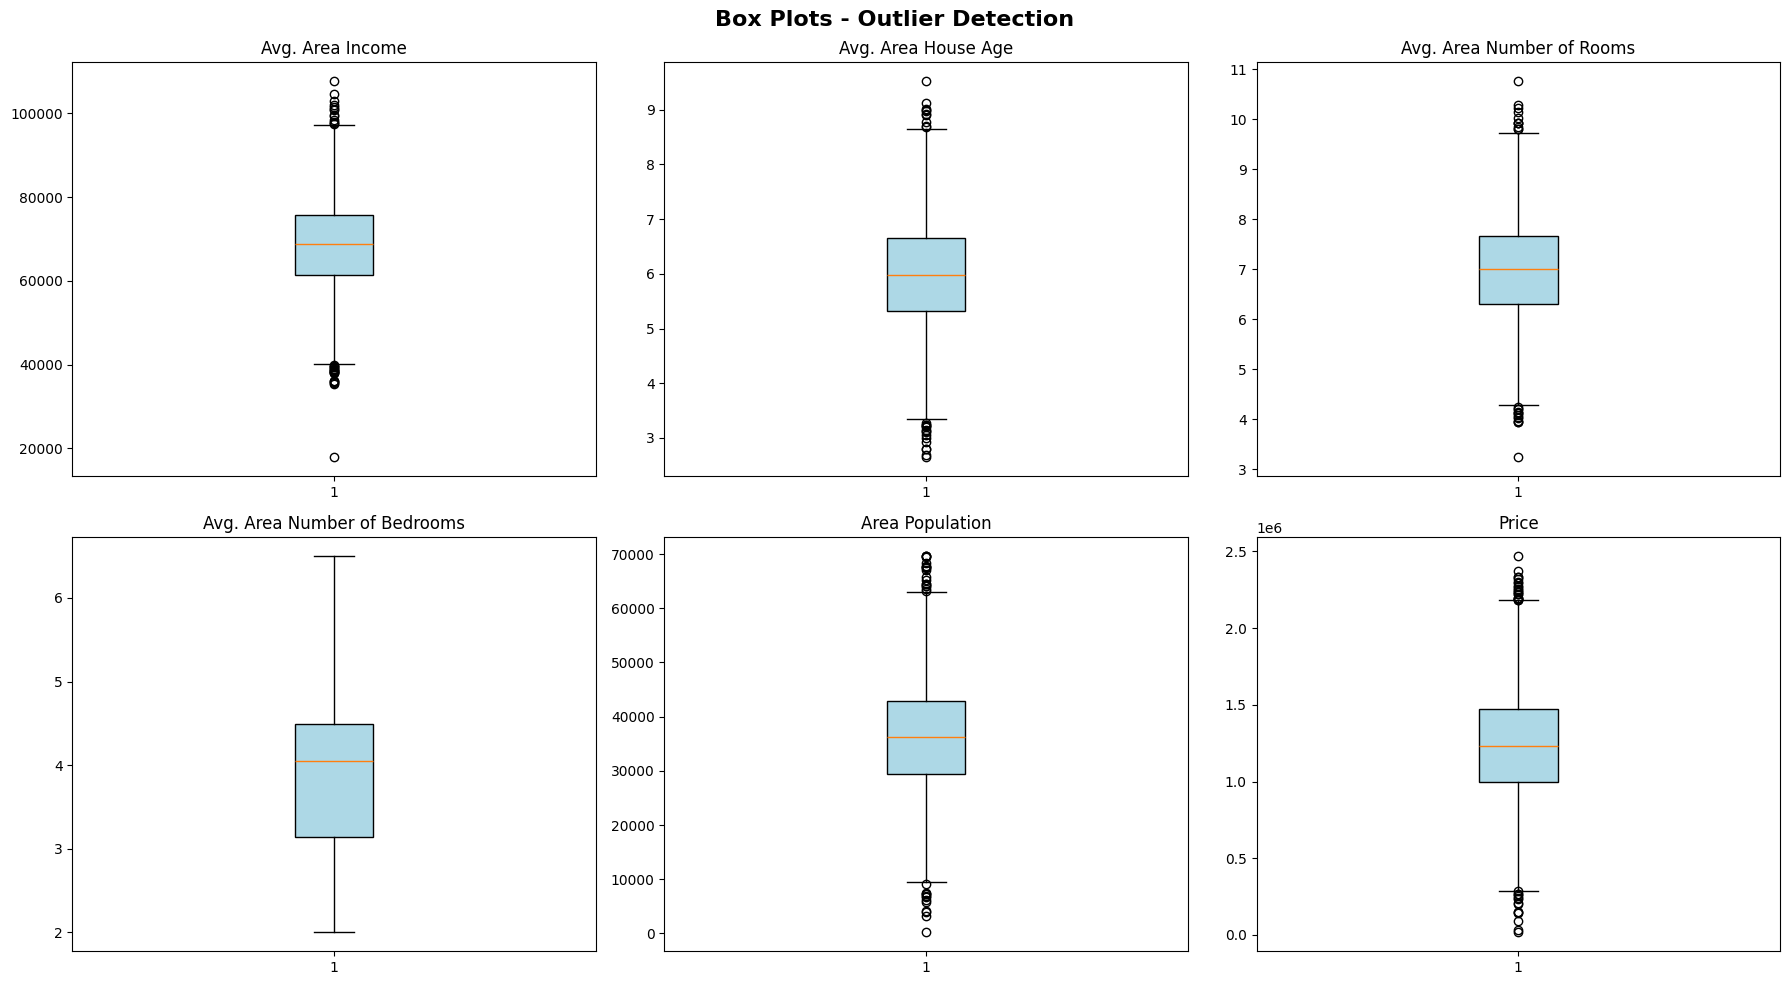

In [11]:
# Box plots to detect outliers
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Box Plots - Outlier Detection', fontsize=16, fontweight='bold')

for idx, col in enumerate(numeric_cols):
    ax = axes[idx // 3, idx % 3]
    ax.boxplot(df[col], patch_artist=True, 
               boxprops=dict(facecolor='lightblue'))
    ax.set_title(col, fontsize=12)

plt.tight_layout()
plt.show()

## 4. Data Preprocessing

In [12]:
# Since Logistic Regression requires a classification target,
# we convert the continuous 'Price' into a binary target:
# 1 = Above median price (High), 0 = Below median price (Low)

median_price = df['Price'].median()
print(f"Median Price: ${median_price:,.2f}")

df['Price_Category'] = (df['Price'] >= median_price).astype(int)
print(f"\nTarget variable distribution:")
print(df['Price_Category'].value_counts())
print(f"\n0 = Below Median (Low Price)")
print(f"1 = Above Median (High Price)")

Median Price: $1,232,669.38

Target variable distribution:
Price_Category
0    2500
1    2500
Name: count, dtype: int64

0 = Below Median (Low Price)
1 = Above Median (High Price)


In [13]:
# Drop the original Price column and Address
# Address will be encoded first, then dropped if not useful

# Extract State from Address as a useful categorical feature
df['State'] = df['Address'].apply(lambda x: x.strip().split(' ')[-2])
print("Extracted 'State' from Address:")
print(df['State'].value_counts())

# Drop Address and Price columns
df_processed = df.drop(['Address', 'Price'], axis=1)
print(f"\nProcessed DataFrame shape: {df_processed.shape}")
df_processed.head()

Extracted 'State' from Address:
State
AA    177
AP    170
AE    167
OR     91
GU     91
     ... 
KS     67
AK     67
IL     64
MD     62
VI     55
Name: count, Length: 62, dtype: int64

Processed DataFrame shape: (5000, 7)


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price_Category,State
0,79545.458574,5.682861,7.009188,4.09,23086.800503,0,NE
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1,CA
2,61287.067179,5.865890,8.512727,5.13,36882.159400,0,WI
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1,AP
4,59982.197226,5.040555,7.839388,4.23,26354.109472,0,AE


In [14]:
# Handle missing values (if any)
print("Missing values before handling:")
print(df_processed.isnull().sum())

# Fill numeric columns with median
numeric_cols_proc = df_processed.select_dtypes(include=[np.number]).columns
for col in numeric_cols_proc:
    if df_processed[col].isnull().sum() > 0:
        df_processed[col].fillna(df_processed[col].median(), inplace=True)

print("\nMissing values after handling:")
print(df_processed.isnull().sum())

Missing values before handling:
Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price_Category                  0
State                           0
dtype: int64

Missing values after handling:
Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price_Category                  0
State                           0
dtype: int64


## 5. Feature and Encoding Techniques

In [15]:
# --- Label Encoding ---
print("="*60)
print("LABEL ENCODING")
print("="*60)

le = LabelEncoder()
df_label_encoded = df_processed.copy()
df_label_encoded['State_LabelEncoded'] = le.fit_transform(df_label_encoded['State'])

print("\nLabel Encoding Mapping:")
for cls, lbl in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {cls} -> {lbl}")

print("\nAfter Label Encoding:")
df_label_encoded[['State', 'State_LabelEncoded']].head(10)

LABEL ENCODING

Label Encoding Mapping:
  AA -> 0
  AE -> 1
  AK -> 2
  AL -> 3
  AP -> 4
  AR -> 5
  AS -> 6
  AZ -> 7
  CA -> 8
  CO -> 9
  CT -> 10
  DC -> 11
  DE -> 12
  FL -> 13
  FM -> 14
  GA -> 15
  GU -> 16
  HI -> 17
  IA -> 18
  ID -> 19
  IL -> 20
  IN -> 21
  KS -> 22
  KY -> 23
  LA -> 24
  MA -> 25
  MD -> 26
  ME -> 27
  MH -> 28
  MI -> 29
  MN -> 30
  MO -> 31
  MP -> 32
  MS -> 33
  MT -> 34
  NC -> 35
  ND -> 36
  NE -> 37
  NH -> 38
  NJ -> 39
  NM -> 40
  NV -> 41
  NY -> 42
  OH -> 43
  OK -> 44
  OR -> 45
  PA -> 46
  PR -> 47
  PW -> 48
  RI -> 49
  SC -> 50
  SD -> 51
  TN -> 52
  TX -> 53
  UT -> 54
  VA -> 55
  VI -> 56
  VT -> 57
  WA -> 58
  WI -> 59
  WV -> 60
  WY -> 61

After Label Encoding:


,State,State_LabelEncoded
0,NE,37
1,CA,8
2,WI,59
3,AP,4
4,AE,1
5,KS,22
6,CO,9
7,TN,52
8,AA,0
9,AE,1


In [16]:
# --- One-Hot Encoding ---
print("="*60)
print("ONE-HOT ENCODING")
print("="*60)

df_onehot = pd.get_dummies(df_processed, columns=['State'], prefix='State', drop_first=True)
print(f"\nShape after One-Hot Encoding: {df_onehot.shape}")
print(f"\nNew columns created: {[col for col in df_onehot.columns if 'State_' in col]}")
df_onehot.head()

ONE-HOT ENCODING

Shape after One-Hot Encoding: (5000, 67)

New columns created: ['State_AE', 'State_AK', 'State_AL', 'State_AP', 'State_AR', 'State_AS', 'State_AZ', 'State_CA', 'State_CO', 'State_CT', 'State_DC', 'State_DE', 'State_FL', 'State_FM', 'State_GA', 'State_GU', 'State_HI', 'State_IA', 'State_ID', 'State_IL', 'State_IN', 'State_KS', 'State_KY', 'State_LA', 'State_MA', 'State_MD', 'State_ME', 'State_MH', 'State_MI', 'State_MN', 'State_MO', 'State_MP', 'State_MS', 'State_MT', 'State_NC', 'State_ND', 'State_NE', 'State_NH', 'State_NJ', 'State_NM', 'State_NV', 'State_NY', 'State_OH', 'State_OK', 'State_OR', 'State_PA', 'State_PR', 'State_PW', 'State_RI', 'State_SC', 'State_SD', 'State_TN', 'State_TX', 'State_UT', 'State_VA', 'State_VI', 'State_VT', 'State_WA', 'State_WI', 'State_WV', 'State_WY']


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price_Category,State_AE,State_AK,State_AL,State_AP,...,State_TN,State_TX,State_UT,State_VA,State_VI,State_VT,State_WA,State_WI,State_WV,State_WY
0,79545.458574,5.682861,7.009188,4.09,23086.800503,0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,61287.067179,5.865890,8.512727,5.13,36882.159400,0,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,59982.197226,5.040555,7.839388,4.23,26354.109472,0,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [17]:
# --- Feature Scaling (StandardScaler) ---
print("="*60)
print("FEATURE SCALING (StandardScaler)")
print("="*60)

# Using the one-hot encoded dataframe
X = df_onehot.drop('Price_Category', axis=1)
y = df_onehot['Price_Category']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print("\nBefore Scaling:")
print(X.describe().loc[['mean', 'std']].T)
print("\nAfter Scaling:")
print(X_scaled.describe().loc[['mean', 'std']].T)

FEATURE SCALING (StandardScaler)

Before Scaling:
                                      mean           std
Avg. Area Income              68583.108984  10657.991214
Avg. Area House Age               5.977222      0.991456
Avg. Area Number of Rooms         6.987792      1.005833
Avg. Area Number of Bedrooms      3.981330      1.234137
Area Population               36163.516039   9925.650114

After Scaling:
                                      mean     std
Avg. Area Income             -2.167155e-17  1.0001
Avg. Area House Age           4.263256e-18  1.0001
Avg. Area Number of Rooms    -4.135359e-16  1.0001
Avg. Area Number of Bedrooms -2.088996e-16  1.0001
Area Population              -3.041123e-16  1.0001
...                                    ...     ...
State_VT                      2.522427e-17  1.0001
State_WA                     -1.847411e-17  1.0001
State_WI                      2.415845e-17  1.0001
State_WV                     -1.421085e-17  1.0001
State_WY                      7

## 6. Feature Selection

METHOD 1: CORRELATION-BASED FEATURE SELECTION

Correlation of features with target (absolute values):
Avg. Area Income                5.058305e-01
Avg. Area House Age             3.654728e-01
Area Population                 3.293472e-01
Avg. Area Number of Rooms       2.627968e-01
Avg. Area Number of Bedrooms    1.303794e-01
                                    ...     
State_GU                        1.496176e-03
State_OR                        1.496176e-03
State_MD                        1.656615e-17
State_SD                        9.589187e-18
State_NH                        7.117539e-18
Name: Price_Category, Length: 66, dtype: float64


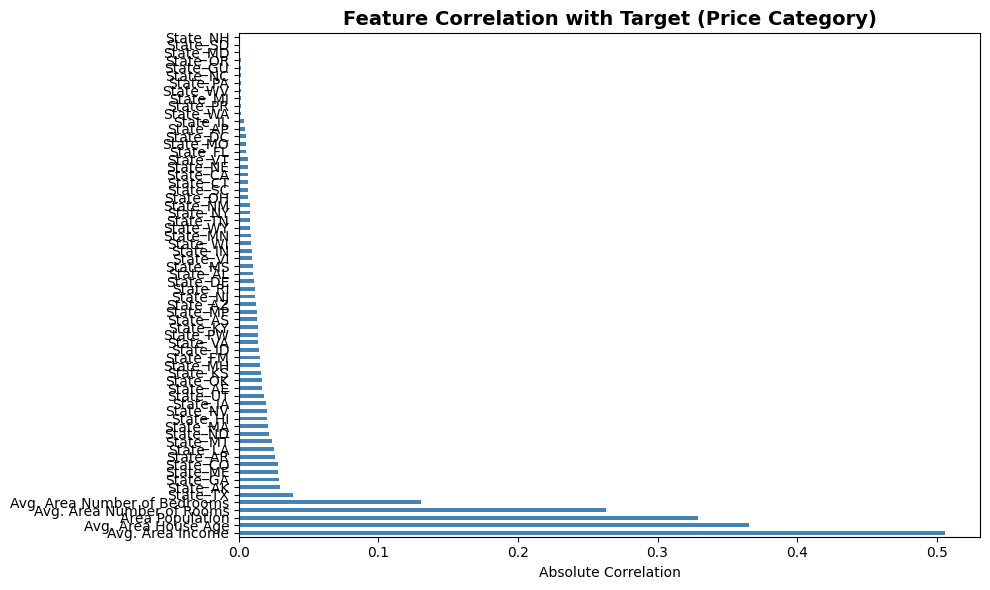

In [18]:
# --- Method 1: Correlation-based Feature Selection ---
print("="*60)
print("METHOD 1: CORRELATION-BASED FEATURE SELECTION")
print("="*60)

# Correlation with target
correlation_with_target = df_onehot.corr()['Price_Category'].drop('Price_Category').abs().sort_values(ascending=False)
print("\nCorrelation of features with target (absolute values):")
print(correlation_with_target)

# Visualize
plt.figure(figsize=(10, 6))
correlation_with_target.plot(kind='barh', color='steelblue')
plt.title('Feature Correlation with Target (Price Category)', fontsize=14, fontweight='bold')
plt.xlabel('Absolute Correlation')
plt.tight_layout()
plt.show()

METHOD 2: MUTUAL INFORMATION FEATURE SELECTION

Mutual Information Scores:
Avg. Area Income             0.141219
Avg. Area House Age          0.071440
Area Population              0.066038
Avg. Area Number of Rooms    0.040020
State_ID                     0.012735
                               ...   
State_ND                     0.000000
State_PR                     0.000000
State_PA                     0.000000
State_RI                     0.000000
State_WI                     0.000000
Length: 66, dtype: float64


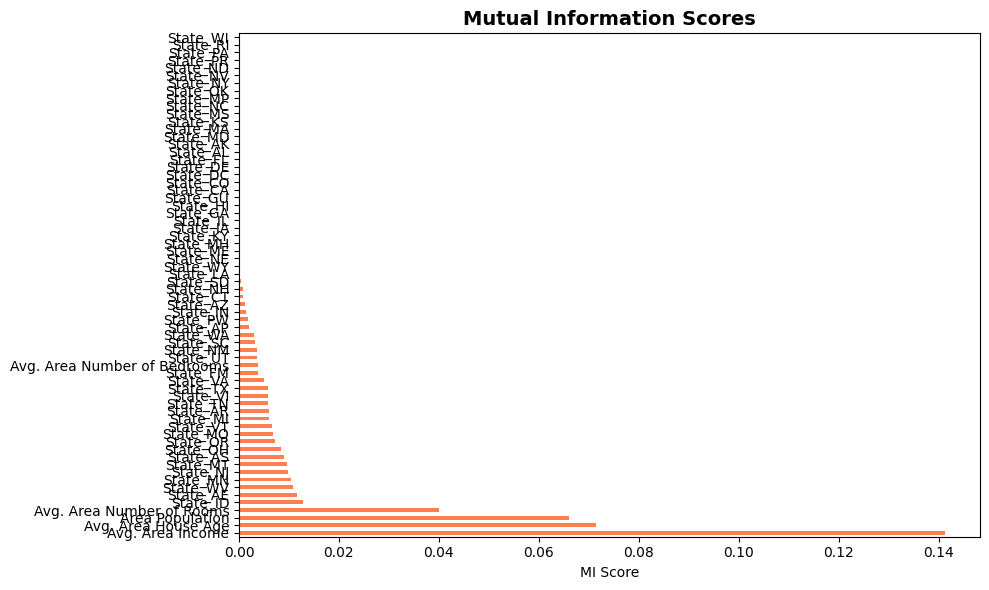

In [19]:
# --- Method 2: Mutual Information ---
print("="*60)
print("METHOD 2: MUTUAL INFORMATION FEATURE SELECTION")
print("="*60)

mi_scores = mutual_info_classif(X_scaled, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

print("\nMutual Information Scores:")
print(mi_series)

plt.figure(figsize=(10, 6))
mi_series.plot(kind='barh', color='coral')
plt.title('Mutual Information Scores', fontsize=14, fontweight='bold')
plt.xlabel('MI Score')
plt.tight_layout()
plt.show()

METHOD 3: SelectKBest (chi2)

Chi-Squared Scores:
Avg. Area Income                31.820815
Avg. Area House Age             28.645510
Area Population                 21.372223
Avg. Area Number of Bedrooms    14.516395
Avg. Area Number of Rooms       12.374999
                                  ...    
State_GU                         0.010989
State_OR                         0.010989
State_MD                         0.000000
State_NH                         0.000000
State_SD                         0.000000
Length: 66, dtype: float64

Top 5 Selected Features: ['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population']


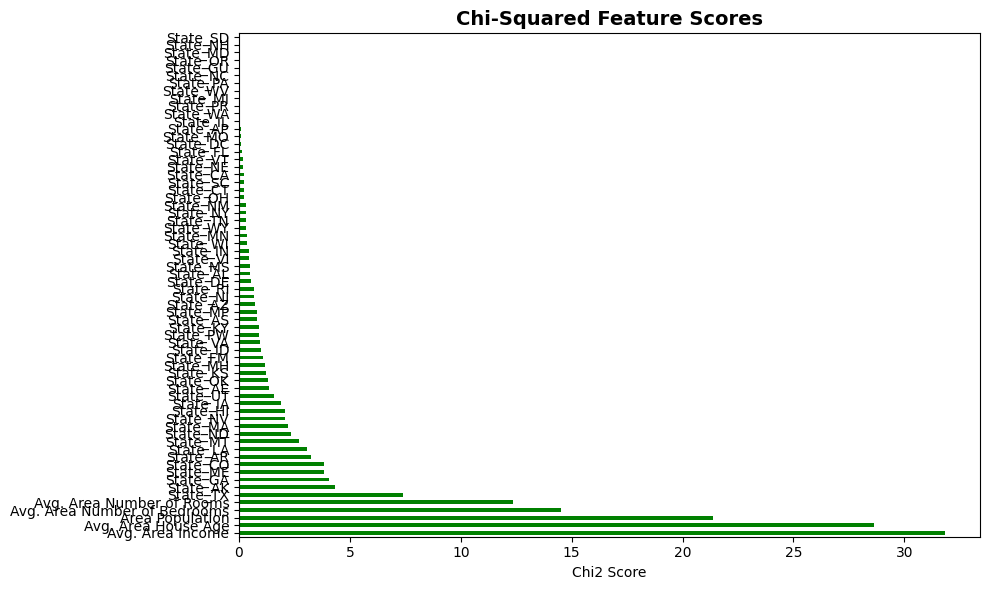

In [20]:
# --- Method 3: SelectKBest with chi2 ---
print("="*60)
print("METHOD 3: SelectKBest (chi2)")
print("="*60)

# chi2 requires non-negative features, so we use MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
X_minmax = MinMaxScaler().fit_transform(X)

selector = SelectKBest(chi2, k=5)
X_selected = selector.fit_transform(X_minmax, y)

chi2_scores = pd.Series(selector.scores_, index=X.columns).sort_values(ascending=False)
print("\nChi-Squared Scores:")
print(chi2_scores)

selected_features = X.columns[selector.get_support()].tolist()
print(f"\nTop 5 Selected Features: {selected_features}")

plt.figure(figsize=(10, 6))
chi2_scores.plot(kind='barh', color='green')
plt.title('Chi-Squared Feature Scores', fontsize=14, fontweight='bold')
plt.xlabel('Chi2 Score')
plt.tight_layout()
plt.show()

## 7. Build Logistic Regression Model

In [21]:
# Use all features (scaled)
print("="*60)
print("TRAIN-TEST SPLIT")
print("="*60)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size:  {X_test.shape[0]}")
print(f"\nTraining set class distribution:\n{y_train.value_counts()}")
print(f"\nTesting set class distribution:\n{y_test.value_counts()}")

TRAIN-TEST SPLIT
Training set size: 4000
Testing set size:  1000

Training set class distribution:
Price_Category
1    2000
0    2000
Name: count, dtype: int64

Testing set class distribution:
Price_Category
0    500
1    500
Name: count, dtype: int64


In [22]:
# Build the Logistic Regression Model
print("="*60)
print("LOGISTIC REGRESSION MODEL")
print("="*60)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# Predictions
y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

print("\nModel trained successfully!")
print(f"\nModel Coefficients:")
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': log_reg.coef_[0]})
coef_df = coef_df.sort_values('Coefficient', ascending=False)
print(coef_df.to_string(index=False))
print(f"\nIntercept: {log_reg.intercept_[0]:.4f}")

LOGISTIC REGRESSION MODEL

Model trained successfully!

Model Coefficients:
                     Feature  Coefficient
            Avg. Area Income     3.988760
         Avg. Area House Age     2.860119
             Area Population     2.682387
   Avg. Area Number of Rooms     2.193069
                    State_MD     0.134819
                    State_NC     0.105524
                    State_PA     0.103078
                    State_IA     0.100460
                    State_DE     0.084516
                    State_VA     0.081719
                    State_KS     0.077343
                    State_OK     0.063093
                    State_WA     0.058488
                    State_OR     0.046732
                    State_SC     0.046136
                    State_GU     0.045475
                    State_AE     0.044248
                    State_IL     0.043168
                    State_AS     0.041075
                    State_HI     0.034744
                    State_NY     0.031061


## 8. Model Evaluation

In [23]:
# --- Accuracy ---
print("="*60)
print("MODEL EVALUATION METRICS")
print("="*60)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# --- Classification Report ---
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Low Price (0)', 'High Price (1)']))

# --- ROC-AUC Score ---
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

MODEL EVALUATION METRICS

Accuracy: 0.9080 (90.80%)

CLASSIFICATION REPORT
                precision    recall  f1-score   support

 Low Price (0)       0.93      0.88      0.91       500
High Price (1)       0.89      0.94      0.91       500

      accuracy                           0.91      1000
     macro avg       0.91      0.91      0.91      1000
  weighted avg       0.91      0.91      0.91      1000

ROC-AUC Score: 0.9717


CONFUSION MATRIX


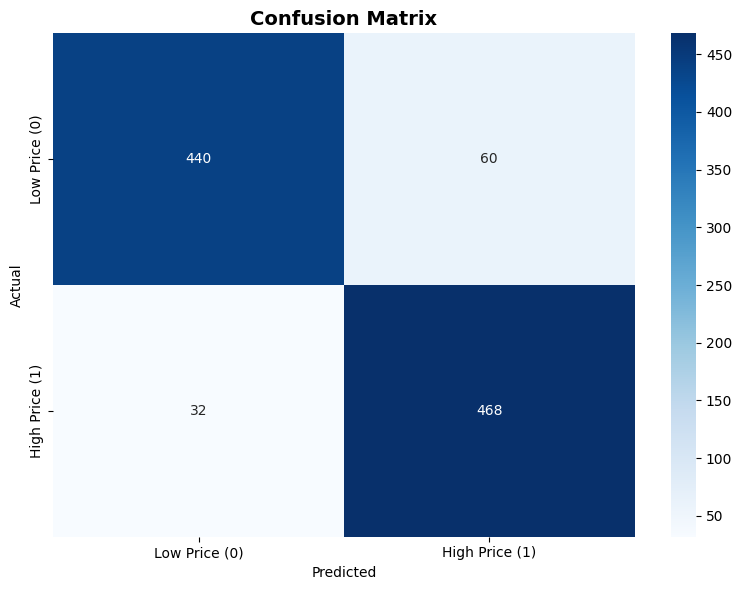


True Negatives:  440
False Positives: 60
False Negatives: 32
True Positives:  468


In [24]:
# --- Confusion Matrix ---
print("="*60)
print("CONFUSION MATRIX")
print("="*60)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Price (0)', 'High Price (1)'],
            yticklabels=['Low Price (0)', 'High Price (1)'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

print(f"\nTrue Negatives:  {cm[0][0]}")
print(f"False Positives: {cm[0][1]}")
print(f"False Negatives: {cm[1][0]}")
print(f"True Positives:  {cm[1][1]}")

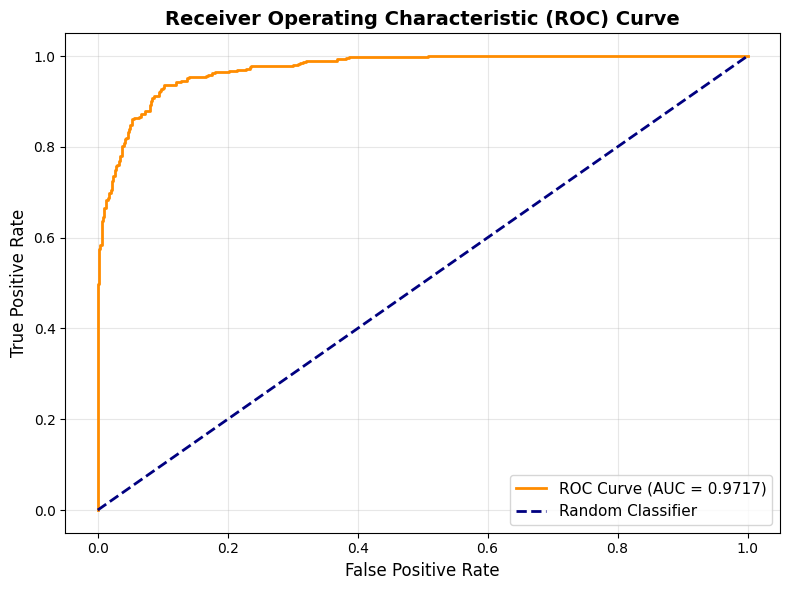

In [25]:
# --- ROC Curve ---
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

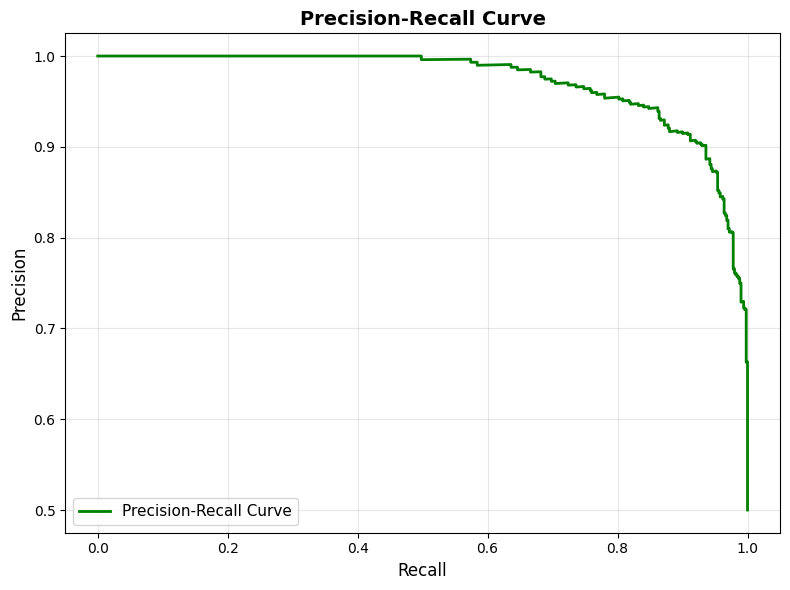

In [26]:
# --- Precision-Recall Curve ---
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='green', lw=2, label='Precision-Recall Curve')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

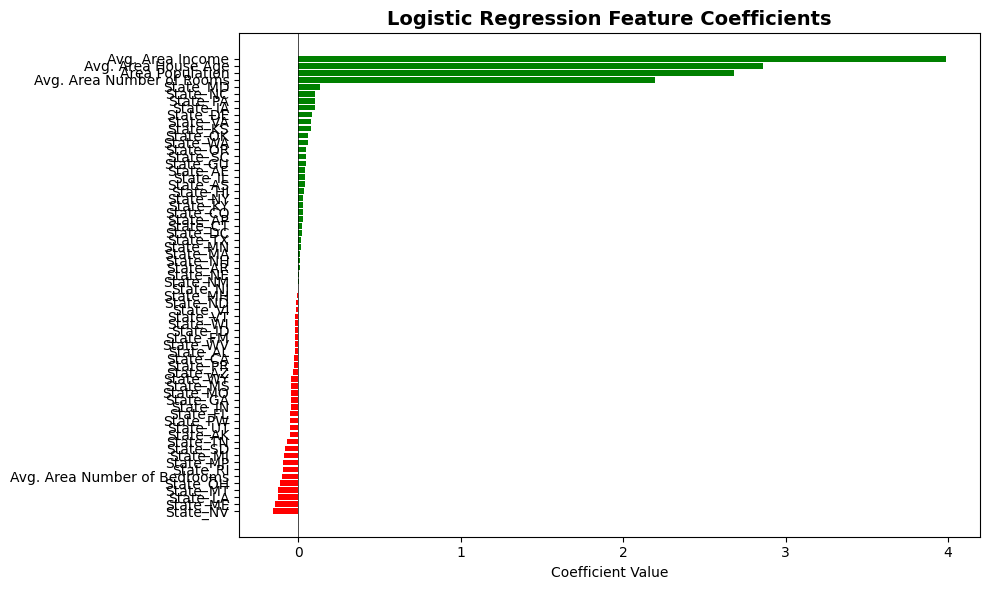

In [27]:
# --- Feature Importance (Coefficient Magnitude) ---
plt.figure(figsize=(10, 6))
coef_df_sorted = coef_df.sort_values('Coefficient')
colors = ['green' if c > 0 else 'red' for c in coef_df_sorted['Coefficient']]
plt.barh(coef_df_sorted['Feature'], coef_df_sorted['Coefficient'], color=colors)
plt.title('Logistic Regression Feature Coefficients', fontsize=14, fontweight='bold')
plt.xlabel('Coefficient Value')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

## 9. Model with Selected Features

In [28]:
# Build model using only top selected features from SelectKBest
print("="*60)
print("LOGISTIC REGRESSION WITH SELECTED FEATURES")
print("="*60)

print(f"\nUsing top 5 features: {selected_features}")

X_train_sel = X_train[selected_features]
X_test_sel = X_test[selected_features]

log_reg_sel = LogisticRegression(max_iter=1000, random_state=42)
log_reg_sel.fit(X_train_sel, y_train)

y_pred_sel = log_reg_sel.predict(X_test_sel)
y_pred_proba_sel = log_reg_sel.predict_proba(X_test_sel)[:, 1]

accuracy_sel = accuracy_score(y_test, y_pred_sel)
roc_auc_sel = roc_auc_score(y_test, y_pred_proba_sel)

print(f"\nAccuracy (Selected Features): {accuracy_sel:.4f} ({accuracy_sel*100:.2f}%)")
print(f"ROC-AUC (Selected Features):  {roc_auc_sel:.4f}")

print("\nClassification Report (Selected Features):")
print(classification_report(y_test, y_pred_sel, target_names=['Low Price (0)', 'High Price (1)']))

LOGISTIC REGRESSION WITH SELECTED FEATURES

Using top 5 features: ['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms', 'Avg. Area Number of Bedrooms', 'Area Population']

Accuracy (Selected Features): 0.9160 (91.60%)
ROC-AUC (Selected Features):  0.9740

Classification Report (Selected Features):
                precision    recall  f1-score   support

 Low Price (0)       0.93      0.90      0.91       500
High Price (1)       0.90      0.93      0.92       500

      accuracy                           0.92      1000
     macro avg       0.92      0.92      0.92      1000
  weighted avg       0.92      0.92      0.92      1000



In [29]:
# --- Comparison ---
print("="*60)
print("MODEL COMPARISON: ALL FEATURES vs SELECTED FEATURES")
print("="*60)

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'ROC-AUC Score', 'Number of Features'],
    'All Features': [f'{accuracy:.4f}', f'{roc_auc:.4f}', X.shape[1]],
    'Selected Features': [f'{accuracy_sel:.4f}', f'{roc_auc_sel:.4f}', len(selected_features)]
})
print(comparison.to_string(index=False))

MODEL COMPARISON: ALL FEATURES vs SELECTED FEATURES
            Metric All Features Selected Features
          Accuracy       0.9080            0.9160
     ROC-AUC Score       0.9717            0.9740
Number of Features           66                 5


## 10. Conclusion

### Summary:
1. **Data Statistics**: Explored the USA Housing dataset loaded from Kaggle with 5000 samples and 7 features. Checked for missing values and duplicates.
2. **Preprocessing**: Converted continuous Price to binary classification target (above/below median). Extracted State from Address.
3. **Encoding Techniques**:
   - **Label Encoding**: Applied to convert State categories to numerical values.
   - **One-Hot Encoding**: Applied to avoid ordinal relationship assumption.
4. **Feature Scaling**: Applied StandardScaler to normalize features.
5. **Feature Selection**: Used Correlation analysis, Mutual Information, and Chi-Squared (SelectKBest) methods.
6. **Logistic Regression Model**: Built and evaluated with both all features and selected features.
7. **Evaluation Metrics**: Accuracy, Classification Report, Confusion Matrix, ROC Curve, and Precision-Recall Curve.

---